# Homework Starter — Stage 03: Python Fundamentals

## Instructions
Fill in the cells below to complete your homework. Refer to lecture examples.

In [11]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. NumPy Operations

In [13]:
# TODO: Create a NumPy array and perform vectorized operations
arr = np.array([10, 20, 30, 40, 50])

print("Original array:", arr)
print("Add 5:", arr + 5)
print("Multiply by 2:", arr * 2)
print("Square:", arr ** 2)

Original array: [10 20 30 40 50]
Add 5: [15 25 35 45 55]
Multiply by 2: [ 20  40  60  80 100]
Square: [ 100  400  900 1600 2500]


## 2. Compare Loop vs Vectorization

In [14]:
# TODO: Compare speed using %timeit
large_arr = np.arange(1_000_000)

%timeit [x * 2 for x in large_arr]
%timeit large_arr * 2

52.4 ms ± 268 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
864 μs ± 77 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## 3. Load and Inspect Dataset

In [15]:
# TODO: Load CSV and inspect with .head(), .info(), .describe()
df = pd.read_csv("data/raw/starter_data.csv")

print(df.head())
print()
df.info()

  category  value        date
0        A     10  2025-08-01
1        B     15  2025-08-02
2        A     12  2025-08-03
3        B     18  2025-08-04
4        C     25  2025-08-05

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  10 non-null     object
 1   value     10 non-null     int64 
 2   date      10 non-null     object
dtypes: int64(1), object(2)
memory usage: 368.0+ bytes


In [16]:
print()
print(df.describe())


           value
count  10.000000
mean   17.600000
std     7.381659
min    10.000000
25%    12.250000
50%    14.500000
75%    23.250000
max    30.000000


## 4. Summary Statistics and Groupby

In [17]:
# TODO: Perform groupby and save output to data/processed/
group_summary = df.groupby("category")["value"].agg(["count", "mean", "min", "max"])

print(group_summary)

          count       mean  min  max
category                            
A             4  11.500000   10   13
B             3  15.666667   14   18
C             3  27.666667   25   30


In [18]:
group_summary.to_csv("data/processed/summary.csv")
print("Saved summary to data/processed/summary.csv")

Saved summary to data/processed/summary.csv


In [19]:
def get_summary_stats(df):
    """Return summary statistics for numeric columns."""
    return df.describe()

summary_stats = get_summary_stats(df)
print(summary_stats)

           value
count  10.000000
mean   17.600000
std     7.381659
min    10.000000
25%    12.250000
50%    14.500000
75%    23.250000
max    30.000000


In [20]:
from src.utils import get_summary_stats
summary_stats = get_summary_stats(df)
print(summary_stats)

           value
count  10.000000
mean   17.600000
std     7.381659
min    10.000000
25%    12.250000
50%    14.500000
75%    23.250000
max    30.000000


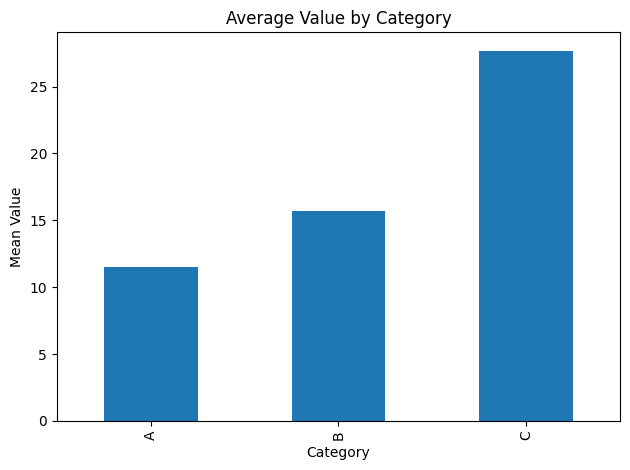

In [21]:
group_summary["mean"].plot(kind="bar")

plt.title("Average Value by Category")
plt.xlabel("Category")
plt.ylabel("Mean Value")
plt.tight_layout()
plt.savefig("data/processed/category_mean.png")
plt.show()